# Model Comparison

This notebook compares the baseline Linear Regression model with Decision Tree and Random Forest regressors. I also expand the feature set used to train the models and compare their test R² values.

## Load Data

In [1]:
# import dependencies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
# load train and test data
train = pd.read_csv('data_clean/cleaned_train_not_encoded.csv')
test = pd.read_csv('data_clean/cleaned_test_not_encoded.csv')

print('Train shape:', train.shape)
print('Test shape:', test.shape)

Train shape: (51267, 37)
Test shape: (12856, 37)


## Feature Sets

I create two feature sets. The first one matches the baseline numeric model. The second one adds a few location columns because location is important for house prices.

In [3]:
# target and leakage columns
target_col = 'ClosePrice'

leakage_cols = [
    'ListPrice',
    'OriginalListPrice',
    'DaysOnMarket',
    'PurchaseContractDate'
]

### Baseline Feature Set

In [4]:
# same basic numeric features as the baseline notebook
baseline_features = [
    'LivingArea',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'LotSizeAcres',
    'YearBuilt',
    'GarageSpaces',
    'ParkingTotal',
    'AssociationFee'
]

missing_indicator_cols = [col for col in train.columns if col.endswith('_missing')]
baseline_features = baseline_features + missing_indicator_cols
baseline_features = [col for col in baseline_features if col in train.columns and col in test.columns]

print('Baseline features:')
print(baseline_features)
print('Number of baseline features:', len(baseline_features))

Baseline features:
['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres', 'YearBuilt', 'GarageSpaces', 'ParkingTotal', 'AssociationFee', 'LotSizeAcres_missing', 'GarageSpaces_missing', 'AssociationFee_missing']
Number of baseline features: 11


### Expanded Feature Set

In [5]:
# add a small number of location/categorical features
location_features = [
    'City',
    'CountyOrParish',
    'PostalCode',
    'MLSAreaMajor',
    'HighSchoolDistrict'
]

location_features = [col for col in location_features if col in train.columns and col in test.columns]
expanded_features = baseline_features + location_features

print('Expanded features:')
print(expanded_features)
print('Number of expanded features before encoding:', len(expanded_features))

Expanded features:
['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres', 'YearBuilt', 'GarageSpaces', 'ParkingTotal', 'AssociationFee', 'LotSizeAcres_missing', 'GarageSpaces_missing', 'AssociationFee_missing', 'City', 'CountyOrParish', 'PostalCode', 'MLSAreaMajor', 'HighSchoolDistrict']
Number of expanded features before encoding: 16


## Prepare Modeling Data

The expanded feature set has categorical columns, so I use one-hot encoding with `pd.get_dummies`. I fit the numeric medians using the training data only.

In [6]:
# helper function to prepare train/test features
def prepare_features(feature_cols):
    X_train = train[feature_cols].copy()
    X_test = test[feature_cols].copy()
    y_train = train[target_col].copy()
    y_test = test[target_col].copy()
    
    categorical_cols = [col for col in feature_cols if col in location_features]
    numeric_cols = [col for col in feature_cols if col not in categorical_cols]
    
    # numeric columns use the training median to impute
    for col in numeric_cols:
        X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
        X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
        median_value = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_value)
        X_test[col] = X_test[col].fillna(median_value)
    
    # categorical columns are converted to strings before one-hot encoding
    for col in categorical_cols:
        X_train[col] = X_train[col].where(X_train[col].notna(), 'Unknown').astype(str).str.strip()
        X_test[col] = X_test[col].where(X_test[col].notna(), 'Unknown').astype(str).str.strip()
        X_train.loc[X_train[col] == '', col] = 'Unknown'
        X_test.loc[X_test[col] == '', col] = 'Unknown'
    
    if len(categorical_cols) > 0:
        X_train = pd.get_dummies(X_train, columns=categorical_cols)
        X_test = pd.get_dummies(X_test, columns=categorical_cols)
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    
    return X_train, X_test, y_train, y_test

In [7]:
# prepare both feature sets
X_train_baseline, X_test_baseline, y_train, y_test = prepare_features(baseline_features)
X_train_expanded, X_test_expanded, _, _ = prepare_features(expanded_features)

print('Baseline X_train shape:', X_train_baseline.shape)
print('Baseline X_test shape:', X_test_baseline.shape)
print('Expanded X_train shape:', X_train_expanded.shape)
print('Expanded X_test shape:', X_test_expanded.shape)

Baseline X_train shape: (51267, 11)
Baseline X_test shape: (12856, 11)
Expanded X_train shape: (51267, 1056)
Expanded X_test shape: (12856, 1056)


## Train and Evaluate Models

The Linear Regression model is the baseline. I train Decision Tree, Random Forest, and Linear Regression models with the baseline and expanded feature sets.

In [8]:
# evaluate a model and return the main metrics
fitted_models = {}

def evaluate_model(model_name, feature_set_name, model, X_train, X_test):
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    fitted_models[(feature_set_name, model_name)] = model
    
    return {
        'model': model_name,
        'feature_set': feature_set_name,
        'features_after_encoding': X_train.shape[1],
        'train_r2': r2_score(y_train, train_pred),
        'test_r2': r2_score(y_test, test_pred),
        'test_mae': mean_absolute_error(y_test, test_pred),
        'test_rmse': np.sqrt(mean_squared_error(y_test, test_pred))
    }

In [9]:
# train baseline and additional models
results = []

results.append(evaluate_model(
    'Linear Regression',
    'Baseline',
    LinearRegression(),
    X_train_baseline,
    X_test_baseline
))

model_specs = [
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(
        n_estimators=50,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
]

feature_sets = [
    ('Baseline', X_train_baseline, X_test_baseline),
    ('Expanded', X_train_expanded, X_test_expanded)
]

for feature_set_name, X_train_current, X_test_current in feature_sets:
    for model_name, model in model_specs:
        results.append(evaluate_model(
            model_name,
            feature_set_name,
            model,
            X_train_current,
            X_test_current
        ))

In [10]:
# also try linear regression with the expanded feature set
results.append(evaluate_model(
    'Linear Regression',
    'Expanded',
    LinearRegression(),
    X_train_expanded,
    X_test_expanded
))

results_df = pd.DataFrame(results)

baseline_test_r2 = results_df.loc[
    (results_df['model'] == 'Linear Regression') &
    (results_df['feature_set'] == 'Baseline'),
    'test_r2'
].iloc[0]

results_df['r2_change_from_baseline'] = results_df['test_r2'] - baseline_test_r2

pd.set_option('display.float_format', '{:,.3f}'.format)
results_df.sort_values('test_r2', ascending=False)

,model,feature_set,features_after_encoding,train_r2,test_r2,test_mae,test_rmse,r2_change_from_baseline
4,Random Forest,Expanded,1056,0.893,0.802,"243,018.306","463,007.076",0.272
5,Linear Regression,Expanded,1056,0.790,0.794,"294,074.028","472,479.946",0.264
3,Decision Tree,Expanded,1056,1.000,0.666,"303,908.383","601,678.943",0.136
2,Random Forest,Baseline,11,0.797,0.634,"394,683.612","629,918.230",0.104
0,Linear Regression,Baseline,11,0.521,0.530,"475,429.581","713,453.794",0.000
1,Decision Tree,Baseline,11,1.000,0.265,"534,522.492","892,266.561",-0.265


## Test R² Comparison

In [11]:
# make the results table easier to read
pd.set_option('display.float_format', '{:,.3f}'.format)

results_display = results_df.copy()

round_cols = ['train_r2', 'test_r2', 'r2_change_from_baseline']
results_display[round_cols] = results_display[round_cols].round(3)
results_display['test_mae'] = results_display['test_mae'].round(0)
results_display['test_rmse'] = results_display['test_rmse'].round(0)

results_display.sort_values('test_r2', ascending=False)

,model,feature_set,features_after_encoding,train_r2,test_r2,test_mae,test_rmse,r2_change_from_baseline
4,Random Forest,Expanded,1056,0.893,0.802,"243,018.000","463,007.000",0.272
5,Linear Regression,Expanded,1056,0.790,0.794,"294,074.000","472,480.000",0.264
3,Decision Tree,Expanded,1056,1.000,0.666,"303,908.000","601,679.000",0.136
2,Random Forest,Baseline,11,0.797,0.634,"394,684.000","629,918.000",0.104
0,Linear Regression,Baseline,11,0.521,0.530,"475,430.000","713,454.000",0.000
1,Decision Tree,Baseline,11,1.000,0.265,"534,522.000","892,267.000",-0.265


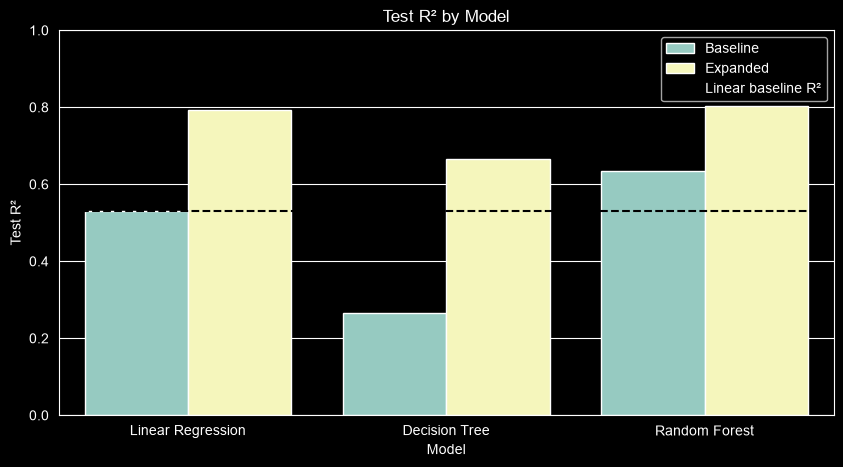

In [12]:
# plot test R squared values
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='model', y='test_r2', hue='feature_set')
plt.axhline(baseline_test_r2, color='black', linestyle='--', label='Linear baseline R²')
plt.ylim(0, 1.0)
plt.title('Test R² by Model')
plt.xlabel('Model')
plt.ylabel('Test R²')
plt.legend()
plt.show()

## Random Forest Feature Importance

The Random Forest can show which encoded features were most useful. This is not a perfect explanation, but it helps describe model behavior.

In [13]:
# show the most important features from the expanded random forest
expanded_forest = fitted_models[('Expanded', 'Random Forest')]

feature_importance = pd.DataFrame({
    'feature': X_train_expanded.columns,
    'importance': expanded_forest.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance.head(15)

,feature,importance
0,LivingArea,0.334
2,BathroomsTotalInteger,0.198
4,YearBuilt,0.055
281,CountyOrParish_Riverside,0.041
3,LotSizeAcres,0.038
284,CountyOrParish_San Bernardino,0.033
291,CountyOrParish_Santa Clara,0.028
999,HighSchoolDistrict_Newport Mesa Unified,0.023
7,AssociationFee,0.023
10,AssociationFee_missing,0.022


## Notes

**Linear Regression:** This is the baseline model from the previous notebook. It is fast and easy to explain, and the baseline test R² is about 0.507. The expanded Linear Regression performed better than the basline, suggesting that the expanded feature set added information about the close price.

**Decision Tree:** The Decision Tree can capture non-linear patterns without needing scaling. Its main weakness is overfitting. In the results, the train R² is much higher than the test R², which means the tree learned the training data too closely. We can manage this with hyperparameter tuning.

**Random Forest:** The Random Forest performed better because it averages many trees. This usually reduces overfitting compared with one Decision Tree. Its weakness is that it is slower and more complex than Linear Regression.

**Feature sets:** The expanded feature set helped the tree models because location fields like city, county, ZIP code, and school district contain important price information. This makes sense for California property prices.

Overall, the Random Forest with the expanded feature set had the best test R² in this comparison. The baseline Linear Regression is still useful because it is simple and interpretable, but the tree-based models handled non-linear patterns and location effects better.